### Experiment 4 – MPS GramNyström half-chain RDM spectrum

This notebook benchmarks the MPS streaming Nyström estimator for the
half-chain reduced density matrix (RDM) eigenvalue spectrum of the
periodic transverse-field Ising model (TFIM) ground state.

$$
\mathbf H = -J\sum_{i=1}^{n}\mathbf Z_i\mathbf Z_{i+1} - h\sum_{i=1}^{n}\mathbf X_i
$$

For each bond dimension $\chi$ and embedding dimension $k$, the estimator
produces approximate RDM eigenvalues from which a von-Neumann entropy
estimate is extracted.  We record the relative entropy error over many
independent trials and compare the recovered spectrum against the exact
free-fermion spectrum.

---

## Load processed data & plot

Loading data/final.json


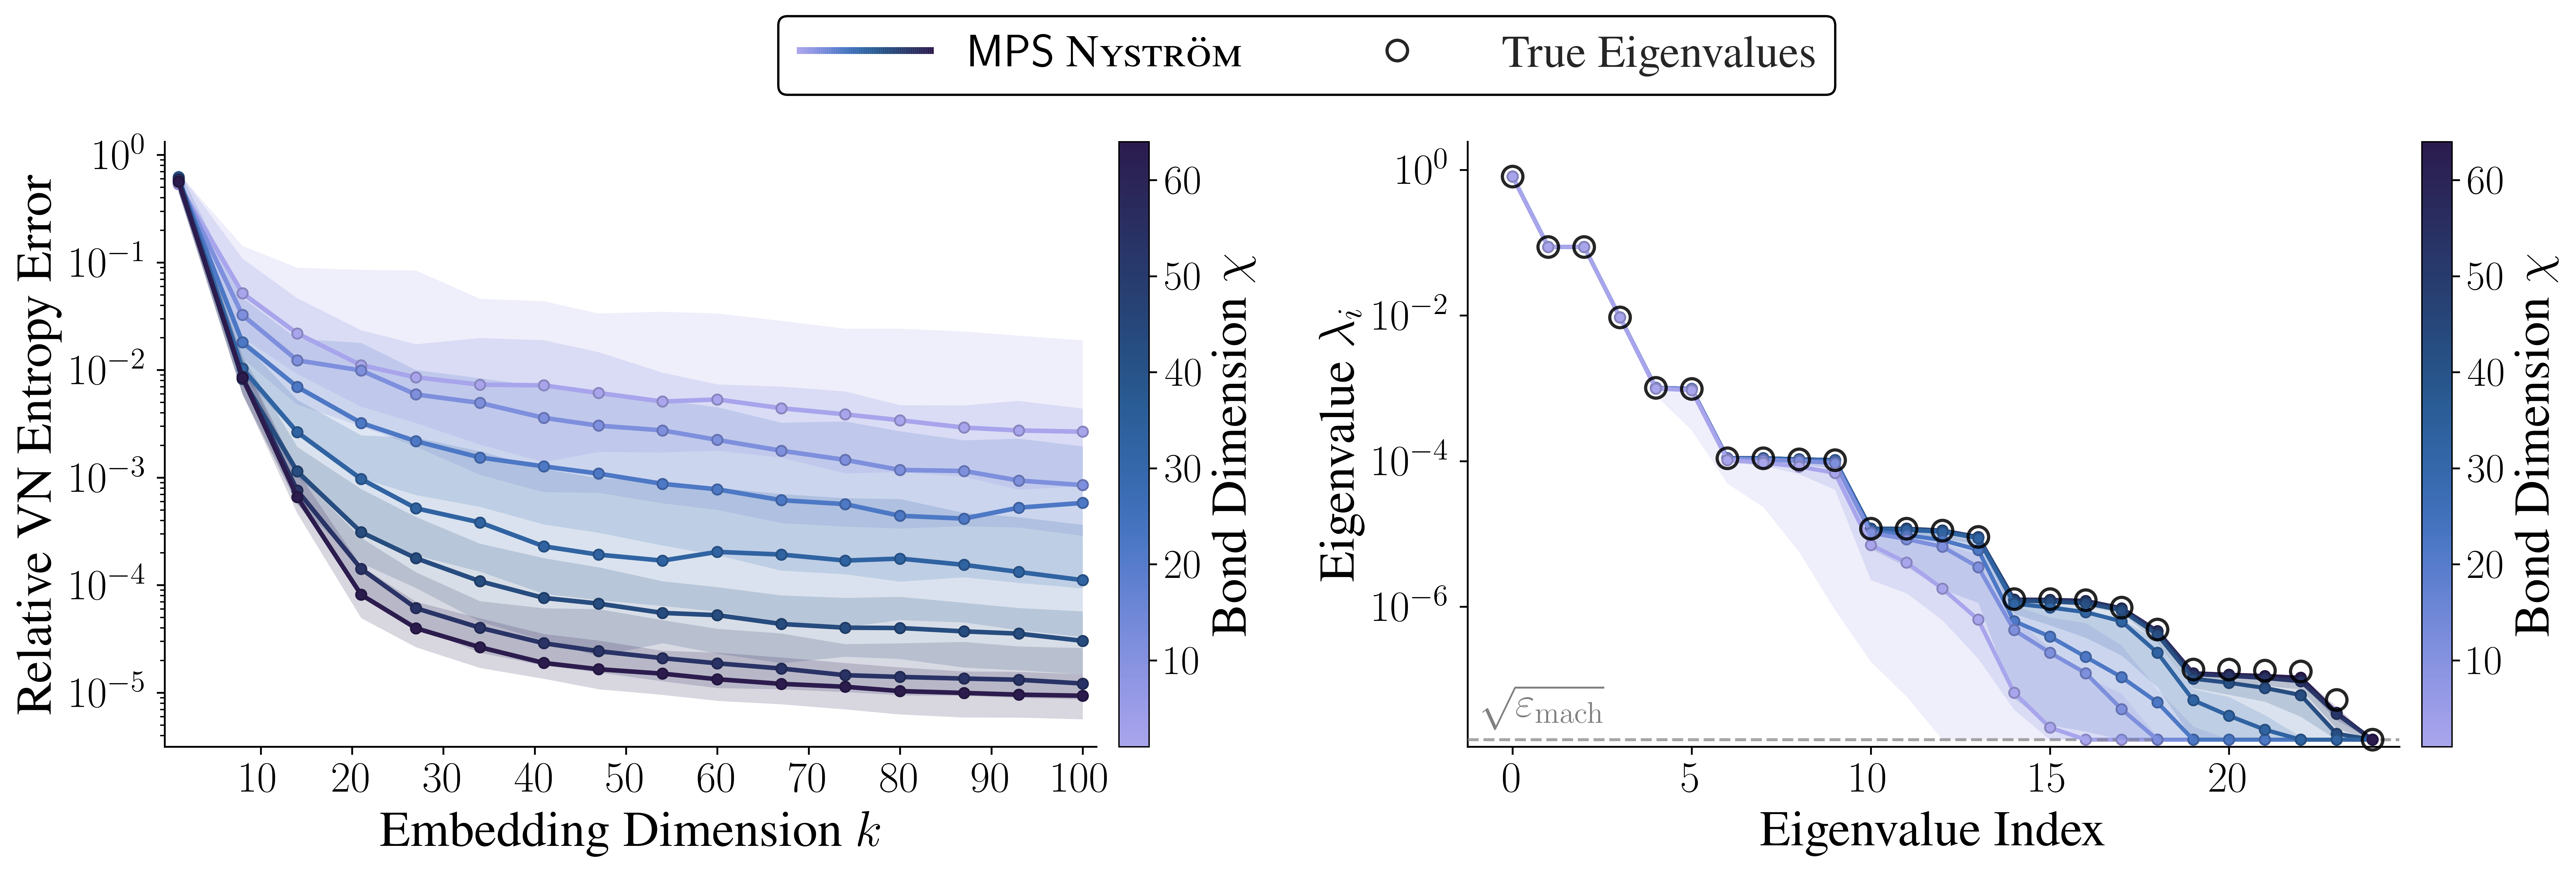

In [1]:
import json
from pathlib import Path
from plotting import load_scientific_cmaps, plot_nystrom_results

load_scientific_cmaps(["oslo", "devon", "lipari", "davos", "lajolla",
                       "acton", "batlow", "glasgow", "bamako", "bilbao"])

data_dir = Path("data")
json_files = sorted(data_dir.glob("final.json"))
if not json_files:
    raise FileNotFoundError(f"No mps_nystrom_streaming_results_*.json found in {data_dir.resolve()}")
data_path = json_files[-1]
print(f"Loading {data_path}")

with data_path.open() as f:
    payload = json.load(f)

meta           = payload["metadata"]
chi_values     = [int(c) for c in meta["chi_values"]]
k_values       = meta["k_values"]
exact_spectrum = meta["exact_spectrum"]
results        = {int(k): v for k, v in payload["results"].items()}

fig, axes = plot_nystrom_results(
    results=results,
    chi_values=chi_values,
    k_values=k_values,
    exact_spectrum=exact_spectrum,
)

## Run

In [1]:
import os, sys
from pathlib import Path

N_THREADS = 8
os.environ.update({
    "MKL_DEBUG_CPU_TYPE":   "5",
    "MKL_THREADING_LAYER":  "INTEL",
    "MKL_DYNAMIC":          "FALSE",
    "OMP_DYNAMIC":          "FALSE",
    "MKL_NUM_THREADS":      str(N_THREADS),
    "OMP_NUM_THREADS":      str(N_THREADS),
    "KMP_AFFINITY":         "granularity=fine,compact,1,0",
    "KMP_BLOCKTIME":        "1",
    "OPENBLAS_NUM_THREADS": "1",
    "BLIS_NUM_THREADS":     "1",
    "NUMEXPR_NUM_THREADS":  "1",
})

%load_ext autoreload
%autoreload 2

import numpy as np

try:
    _HERE = Path(__file__).resolve().parent
except NameError:
    _HERE = Path.cwd().resolve()

_FINALS_DIR = _HERE.parent
if str(_FINALS_DIR) not in sys.path:
    sys.path.insert(0, str(_FINALS_DIR))

from tnrnla import Cutoff, MPS
from tnrnla.quantum.dmrg import dmrg2
from tfim import periodic_tfim_zz_x
from fig4_driver import experiment

In [2]:
# ── Parameters ────────────────────────────────────────────────────────────────
n             = 200
J             = 1.0
h             = 1.1
dmrg_sweeps   = 6
dmrg_cutoff   = 1e-8
guess_chi     = 1

n_trials          = 1
k_values          = [100]  # np.rint(np.linspace(1, 100, 16)).astype(int)
chi_values        = [32]#[1, 2, 4, 8, 16, 32, 64]
base_seed         = 1234
trial_seed_stride = 10000

In [3]:
# ── DMRG ground state ─────────────────────────────────────────────────────────
guess = MPS.rmps(n, guess_chi)
H     = periodic_tfim_zz_x(n, J=J, h=h)

groundstate, energies = dmrg2(
    H, guess,
    sweeps=dmrg_sweeps,
    stop=Cutoff(dmrg_cutoff),
    maxit=600, eig_ncv=32, eig_tol=1e-10,
)
print("DMRG done")
groundstate.show()
print(f"Max bond: {groundstate.max_bond()}")

DMRG done
    │2│4│8│16│31│47│60│70│78│82│86│89│93│96│99│102│104│105│106│107│108│109    
... ▶-▶-▶-▶--▶--▶--▶--▶--▶--▶--▶--▶--▶--▶--▶--▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━ ...
                                 ...                                  
    │108│109│110│111│112│112│113│113│113│114│113│113│113│114│114│114│114│1    
... ▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━ ...
                                 ...                                  
    14│114│114│113│113│112│112│112│112│112│112│112│112│112│111│111│111│111    
... ━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━ ...
                                 ...                                  
    │111│111│111│111│111│111│111│111│111│111│111│110│109│109│109│109│108│1    
... ▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━━━▶━ ...
                                 ...                                  
    08│108│108│108│107│107│107│107│107│107│107│107│108│108│108│107│107│107

In [4]:
# ── Streaming Nyström sweep ────────────────────────────────────────────────────
results, payload = experiment(
    groundstate,
    n=n,
    h=h,
    J=J,
    k_values=k_values,
    chi_values=chi_values,
    n_trials=n_trials,
    base_seed=base_seed,
    trial_seed_stride=trial_seed_stride,
    out_dir="data",
)

exact_spectrum = payload["metadata"]["exact_spectrum"]

/scratch/users/ram900/conda/envs/tnrnla-mkl-samwise/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
                                                                       

Saved to /accounts/projects/mahoneymw/ram900/C/TNrandNLA/experiments/Figure4_MPSNystrom/data/mps_nystrom_streaming_results_20260610_132851.json


In [6]:
print(results)

{32: {'relerr_trials': [[2.7291551072047898e-05]], 'entropy_trials': [[0.6569082258437882]], 'trace_trials': [[0.9999981513164738]], 'spectrum_trials': [[0.8130102523998549, 0.08761631967020601, 0.08748649146081015, 0.009428177552771084, 0.0010175231128261885, 0.0009674101376281825, 0.00010957580752970242, 0.00010935538392888242, 0.00010412638251282228, 0.00010194128172550873, 1.1727706316489259e-05, 1.1675945069985744e-05, 1.0877336803435836e-05, 7.871728170482829e-06, 1.2328043944933064e-06, 1.1658822405179616e-06, 1.1608104257291437e-06, 7.990618746476276e-07, 1.293018833579574e-07, 9.991823398140065e-08, 8.985941003192855e-08, 7.180269192571835e-08, 5.700323424053887e-08, 4.0172592823694844e-09, 3.3593655568074636e-09, 2.4383624130441376e-09, 1.856859639650512e-09, 1.7540129544915466e-09, 9.897075765774656e-10, 9.463449277255388e-10, 7.473000662706198e-10, 6.057020076602191e-10, 3.8653483255772715e-10, 3.4156556593260823e-10, 2.474561547752297e-10, 1.9231047202596633e-10, 1.8099867

## Plot

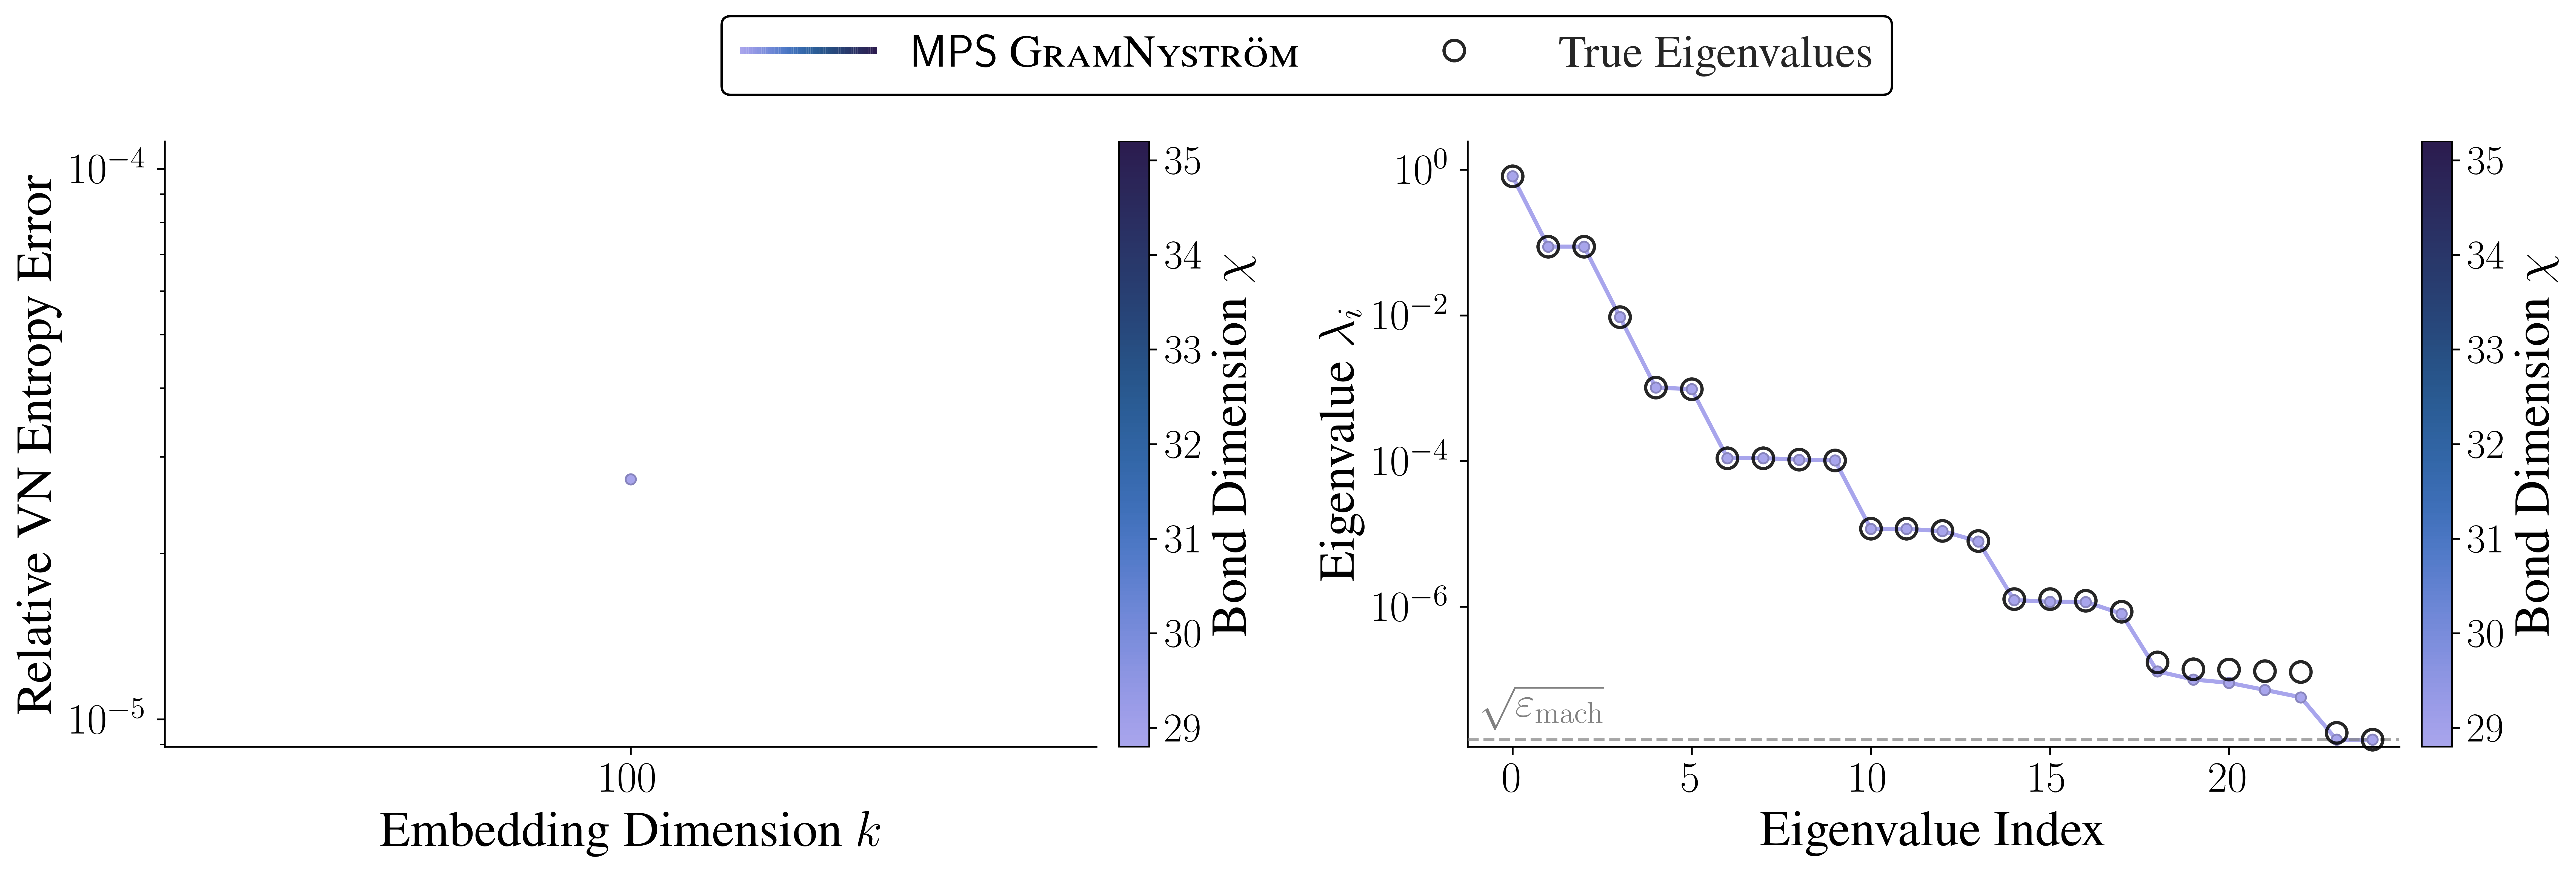

In [5]:
from plotting import load_scientific_cmaps, plot_nystrom_results

load_scientific_cmaps(["oslo", "devon", "lipari", "davos", "lajolla",
                       "acton", "batlow", "glasgow", "bamako", "bilbao"])

fig, axes = plot_nystrom_results(
    results=results,
    chi_values=chi_values,
    k_values=k_values,
    exact_spectrum=exact_spectrum,
)

## (Optional) Save

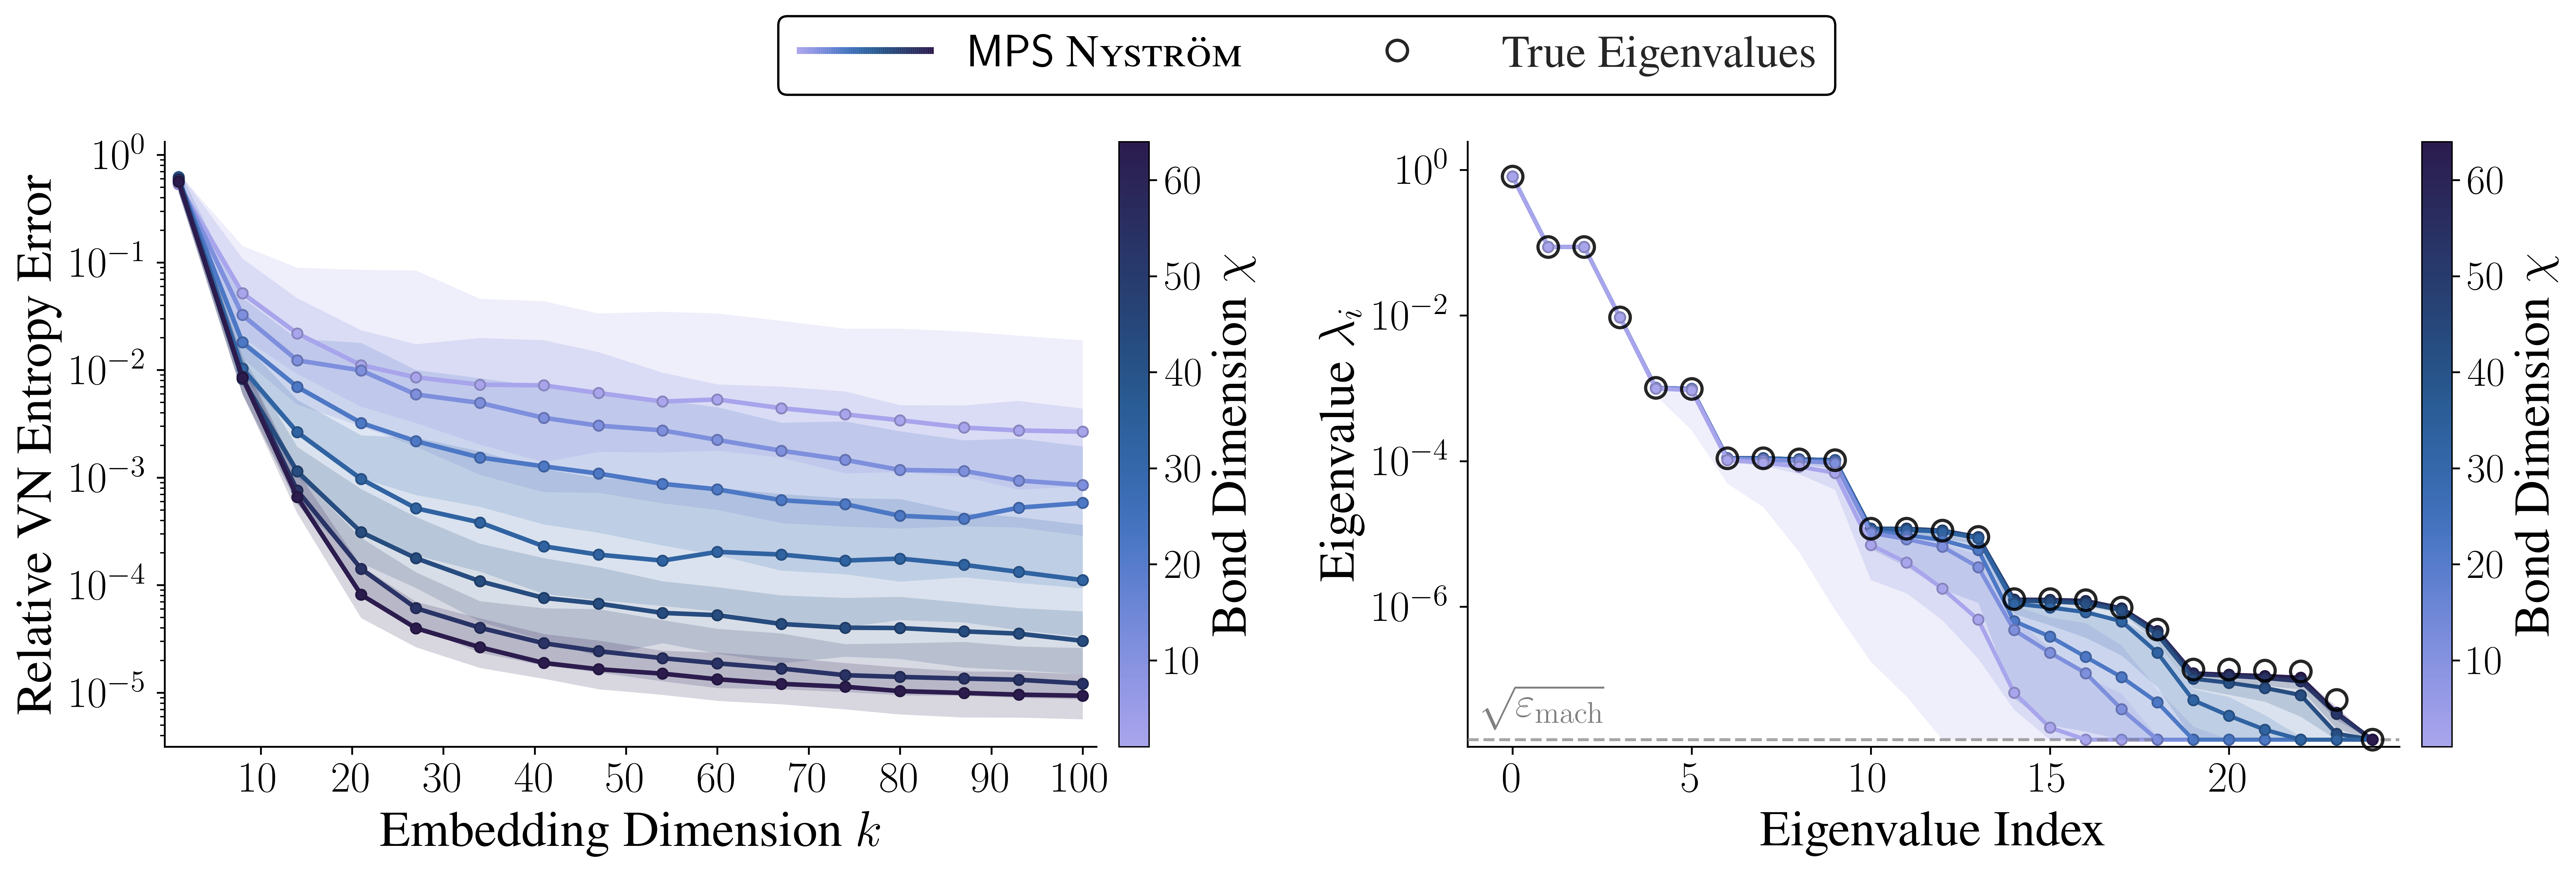

Saved to /accounts/projects/mahoneymw/ram900/C/TNrandNLA/experiments/Figure4_MPSNystrom/figures/Figure4_MPSNystrom.pdf


In [3]:
from pathlib import Path
from plotting import load_scientific_cmaps, plot_nystrom_results

load_scientific_cmaps(["oslo", "devon", "lipari", "davos", "lajolla",
                       "acton", "batlow", "glasgow", "bamako", "bilbao"])

figures_dir = Path("figures")
figures_dir.mkdir(exist_ok=True)

savepath = figures_dir / "Figure4_MPSNystrom.pdf"
fig, axes = plot_nystrom_results(
    results=results,
    chi_values=chi_values,
    k_values=k_values,
    exact_spectrum=exact_spectrum,
    savepath=str(savepath),
)
print(f"Saved to {savepath.resolve()}")